# Downstream applications on the fine-tuned MIMIC-III embeddings

This notebook exercises four downstream applications on top of `gaspard-loeillot/embeddinggemma-mimic-hierarchical`:

1. **Patient-record search** — free-text query → top-k semantically-similar clinical notes
2. **Retrieval-augmented generation (RAG)** — top-k notes + a clinical question → grounded answer with note citations (via `gpt-4o-mini`; falls back to retrieval-only if no `OPENAI_API_KEY`)
3. **Cohort discovery** — patient-level mean-pooled embeddings → nearest-patient lookup, with a Mann-Whitney significance test on ICD-chapter overlap
4. **Trajectory analysis** — per-patient ordered note embeddings → embedding velocity (L2 between consecutive notes) and 2-D PCA, used to surface clinical inflection points

All four are built on a single FAISS `IndexFlatIP` over the 23,657 cached anchor-note embeddings from the 500-patient training subset. All logic is in [`src/rag.py`](../src/rag.py); this notebook is a thin demonstration layer.

In [1]:
# Setup: OMP env vars must be set BEFORE faiss/torch are loaded (Apple Silicon libomp collision).
# rag.py does this internally, but if a kernel was previously initialized you may need to restart it.
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rag import (
    build_index, search, ask,
    find_similar_patients, patient_trajectory,
    evaluate_cohort_discovery,
    patient_level_embeddings,
)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 180)

## 1. Build the corpus index

Loads the 23,657 cached anchor embeddings of the hierarchical fine-tuned model, L2-normalizes them, builds a FAISS `IndexFlatIP` (cosine similarity over unit vectors), and prepares a metadata DataFrame that is row-aligned with the index.

In [2]:
corpus = build_index()
print(f'Index size: {corpus.index.ntotal:,} notes')
print(f'Distinct patients: {corpus.meta["subject_id"].nunique():,}')
print(f'Distinct categories: {corpus.meta["anchor_category"].nunique()}')
print()
print('Notes-per-category (top 10):')
print(corpus.meta['anchor_category'].value_counts().head(10).to_string())

[build_index] loading anchor_embeddings_models_embeddinggemma_hierarchical_best.npy...
  shape=(23657, 768)  dtype=float32  L2-normalized
[build_index] loading metadata...


[build_index] building FAISS IndexFlatIP...
  index size=23657
Index size: 23,657 notes
Distinct patients: 483
Distinct categories: 13

Notes-per-category (top 10):
anchor_category
Nursing/other        14623
Radiology             5281
ECG                   2041
Echo                   471
Discharge summary      432
Nursing                427
Physician              302
Respiratory             20
Nutrition               20
General                 19


## 2. Patient-record search

A query is encoded with the same fine-tuned `SentenceTransformer` that produced the corpus embeddings, then ranked against every note by cosine similarity. The expectation is that retrieved notes share both clinical content and ICD codes with the query intent.

In [3]:
QUERIES = [
    'patient with septic shock requiring vasopressors',
    'post-CABG with new-onset atrial fibrillation',
    'newborn with respiratory distress requiring CPAP',
    'acute kidney injury secondary to contrast nephropathy',
    'altered mental status, hypoglycemia, possible stroke',
]
for q in QUERIES:
    print('=' * 100)
    print(f'QUERY: {q}')
    print('=' * 100)
    df = search(corpus, q, k=5, snippet_chars=140)
    for _, r in df.iterrows():
        print(f"  rank={r['rank']}  sim={r['similarity']:.3f}  pid={r['subject_id']}  cat={r['category'][:20]:<20s}  hadm={r['anchor_hadm_id']}  icd5={r['icd_codes'][:5]}")
        print(f"    {r['snippet']}")
    print()

QUERY: patient with septic shock requiring vasopressors
[CorpusIndex] loading model for query encoding...


  loading from local: /Users/gaspardloeillot/Desktop/Cornell/Senior/contrastive_learning_clinical_embeddings/models/embeddinggemma_hierarchical_best


  rank=1  sim=0.638  pid=2570  cat=Nursing/other         hadm=103250  icd5=['2762', '27652', '03842', 'V08', '5715']
    FOCUS; NURSING PROGRESS NOTE 55 YEAR OLD MAN WITH HEP C, HIV, SP ETOH AND IVDA. NOW WITH FAILING LIVER AND KIDNEYS/ S/P GIB AT OSH. ALSO WIT
  rank=2  sim=0.637  pid=2570  cat=Nursing/other         hadm=103250  icd5=['2762', '27652', '03842', 'V08', '5715']
    MICU WEST Nursing Progress Note  Please see carevue for all objective data. Pt. continues to do quite poorly...on triple pressors, unrespons
  rank=3  sim=0.625  pid=931  cat=Nursing/other         hadm=141560  icd5=['99812', '5185', '4275', '78551', '4241']
    RESPIRATORY CARE: PT W/ 8.0 ORAL ETT IN PLACE. REMAINS ON CMV MODE NOW W/ RR 34/420/1.0/15 PEEP. ABG C/W A METABOLIC ACIDOSIS AND VERY POOR 
  rank=4  sim=0.623  pid=2570  cat=Nursing/other         hadm=103250  icd5=['2762', '27652', '03842', 'V08', '5715']
    Shift Note 1900-0700 55 y/o Male with Hep C cirrhosis (on transplant list) and HIV that was a

  rank=1  sim=0.654  pid=3637  cat=Nursing/other         hadm=157509  icd5=['41401', '5997', '5845', '486', '42731']
    POD #3 CABG AFIB WITH PVC TILL ABOUT 0900 WHEN PT CONVERTED TO NSR RARE PVC NOTED THROUGHOUT THE DAY (SIGNIFICANTLY LESS VEA TODAY COMPARED 
  rank=2  sim=0.636  pid=1125  cat=Nursing/other         hadm=105323  icd5=['41401', '4111', '42731', '4271', '4293']
    PT UPDATE   PT IS S/P CABG X2 ON [**2-9**].    NEURO: PT [**Month/Year (2) 416**] EARLY AM-A&O X3. PLEASANT AND COOPERATIVE. PT VERY CALM.  
  rank=3  sim=0.625  pid=5331  cat=Nursing/other         hadm=142049  icd5=['53081', '4019', '25000', '7802', '4240']
    PT UPDATE   PT IS S/P CABG ON [**4-19**].    NEURO: PT VERY ANXIOUS THIS AM BEFORE [**Month/Day (4) **]. ANXIOUS AFTER BEING EXT. ALSO; SEEM
  rank=4  sim=0.619  pid=1125  cat=Nursing/other         hadm=105323  icd5=['41401', '4111', '42731', '4271', '4293']
    neuro: alert and oriented, cooperative, pain well controlled with percocet.slept in naps  

## 3. Retrieval-augmented generation

Top-5 retrieved notes are concatenated with note IDs and passed to `gpt-4o-mini` with a strict instruction to answer **only** from the retrieved text and to refuse if the answer isn't grounded.

If `OPENAI_API_KEY` (or `OPENAI-API-KEY`) is not set in `.env`, this cell prints retrieval-only results and `answer=None`.

In [4]:
QUESTIONS = [
    'What antibiotics are typically given for gram-negative bacteremia in MICU patients in this corpus?',
    'What signs of liver failure are described in the retrieved notes?',
    'How is fluid status managed in newborns with respiratory distress?',
]
for q in QUESTIONS:
    print('=' * 100)
    print(f'QUESTION: {q}')
    print('=' * 100)
    res = ask(corpus, q, k=5)
    if res.get('answer'):
        print(f'\n[gpt-4o-mini answer]\n{res["answer"]}\n')
    else:
        print(f'\n[no LLM answer: {res.get("note", "")}]\n')
    print('Top-3 retrieved notes:')
    for _, r in res['retrieved'].head(3).iterrows():
        print(f"  Note {r['rank']}  sim={r['similarity']:.3f}  pid={r['subject_id']}  cat={r['category']}  icd5={r['icd_codes'][:5]}")
    print()

QUESTION: What antibiotics are typically given for gram-negative bacteremia in MICU patients in this corpus?



[gpt-4o-mini answer]
The retrieved notes do not answer this question.

Top-3 retrieved notes:
  Note 1  sim=0.442  pid=5161  cat=Nursing/other  icd5=['78039', '5770', '57451', '9974', '5601']
  Note 2  sim=0.426  pid=2592  cat=Nursing/other  icd5=['56212', '2800', '03810', '99591', '5990']
  Note 3  sim=0.425  pid=2322  cat=Nursing/other  icd5=['2769', '5750', '5601', '042', '2554']

QUESTION: What signs of liver failure are described in the retrieved notes?



[gpt-4o-mini answer]
The retrieved notes describe several signs of liver failure, particularly in Note 3. The patient is noted to have:

- Significant confusion and altered mental status, described as "very mildly confused at times" (Note 3).
- Abdominal distension and tautness due to ascites (Note 3).
- Jaundice, indicated by "very jaundiced skin and sclera" (Note 3).
- Elevated creatinine levels, suggesting hepato-renal failure (Note 3).
- Itchiness of the skin (Note 3).

These signs collectively indicate the presence of liver failure in the patient.

Top-3 retrieved notes:
  Note 1  sim=0.547  pid=8466  cat=Nursing/other  icd5=['1550', '7907', '19889', '78559', '5185']
  Note 2  sim=0.504  pid=8466  cat=Radiology  icd5=['1550', '7907', '19889', '78559', '5185']
  Note 3  sim=0.494  pid=7050  cat=Nursing/other  icd5=['99592', '5724', '7895', '5849', '03811']

QUESTION: How is fluid status managed in newborns with respiratory distress?



[gpt-4o-mini answer]
The retrieved notes do not answer this question.

Top-3 retrieved notes:
  Note 1  sim=0.598  pid=7759  cat=Radiology  icd5=['V053', '22801', 'V290', '53081', '77989']
  Note 2  sim=0.581  pid=1759  cat=Radiology  icd5=['V721', 'V502', 'V290', '76519', '7702']
  Note 3  sim=0.577  pid=5758  cat=Nursing/other  icd5=['V3001', '7742', '76405', '77089', 'V053']



## 4. Cohort discovery

Patient-level embeddings are computed as the L2-normalized mean of all anchor-note embeddings for that patient. Cosine similarity over patient-level vectors gives a patient-similarity score. We sanity-check the result with a strict statistical test: do the top-k nearest neighbors share more ICD chapters than random patient pairs?

In [5]:
# Pre-compute patient-level embeddings once and reuse for the rest of this section
sids, patient_embs = patient_level_embeddings(corpus)
print(f'Patient-level embeddings: {patient_embs.shape}')

# Pick a few seed patients with diverse note counts
counts = corpus.meta['subject_id'].value_counts()
seeds = [
    int(counts.index[0]),                          # busiest patient
    int(counts.index[len(counts) // 2]),           # median patient
    int(counts.index[-50]),                        # tail patient
]
for s in seeds:
    print(f'\n=== seed subject_id={s}  (n_anchors={int(counts[s])}) ===')
    df = find_similar_patients(corpus, s, k=5, pooled=(sids, patient_embs))
    display(df)

Patient-level embeddings: (483, 768)

=== seed subject_id=7627  (n_anchors=747) ===


,rank,similarity,subject_id,shared_chapters,n_shared,jaccard_chapter
0,1,0.304613,6766,"[740-759_congenital, 760-779_perinatal, V_supplementary]",3,0.333333
1,2,0.279640,8464,"[460-519_respiratory, 520-579_digestive, 780-799_symptoms]",3,0.214286
2,3,0.265282,9212,"[740-759_congenital, 760-779_perinatal, V_supplementary]",3,0.375000
3,4,0.229894,7403,[V_supplementary],1,0.142857
4,5,0.227494,9294,[460-519_respiratory],1,0.100000



=== seed subject_id=2849  (n_anchors=22) ===


,rank,similarity,subject_id,shared_chapters,n_shared,jaccard_chapter
0,1,0.617185,8255,"[460-519_respiratory, 780-799_symptoms]",2,0.181818
1,2,0.581129,9805,"[240-279_endocrine, 520-579_digestive, 780-799_symptoms, V_supplementary]",4,0.363636
2,3,0.565412,8511,"[290-319_mental, 460-519_respiratory]",2,0.166667
3,4,0.452521,6669,[],0,0.000000
4,5,0.435477,2045,"[240-279_endocrine, 290-319_mental, 520-579_digestive, 780-799_symptoms, V_supplementary]",5,0.384615



=== seed subject_id=3592  (n_anchors=3) ===


,rank,similarity,subject_id,shared_chapters,n_shared,jaccard_chapter
0,1,0.835705,4638,[V_supplementary],1,0.500000
1,2,0.800371,5480,[V_supplementary],1,0.500000
2,3,0.796978,7823,[V_supplementary],1,0.333333
3,4,0.795762,8448,[V_supplementary],1,0.333333
4,5,0.794828,4233,[V_supplementary],1,0.500000


In [6]:
# Quantitative validation: neighbors-vs-random Mann-Whitney U on chapter Jaccard
stats = evaluate_cohort_discovery(corpus, n_seeds=50, k=5, n_random_pairs=1000)
print(json.dumps(stats, indent=2))

{
  "n_seeds": 50,
  "k": 5,
  "n_random_pairs": 1000,
  "neighbor_mean_jaccard": 0.45130021645021645,
  "neighbor_median_jaccard": 0.4226190476190476,
  "random_mean_jaccard": 0.21549398379398377,
  "random_median_jaccard": 0.18181818181818182,
  "lift_mean": 2.09425900670001,
  "mannwhitneyu_one_sided_p": 4.769717015804531e-41
}


## 5. Trajectory analysis

For one patient with many notes, plot:
- L2 distance between consecutive note embeddings as a function of time (top): spikes = candidate inflection points / acuity changes.
- 2-D PCA of the patient's note embeddings (bottom): a continuous trajectory through the embedding space across the admission, colored by note order.

patient 7627: 747 notes  median l2_prev=0.706  max l2_prev=1.159


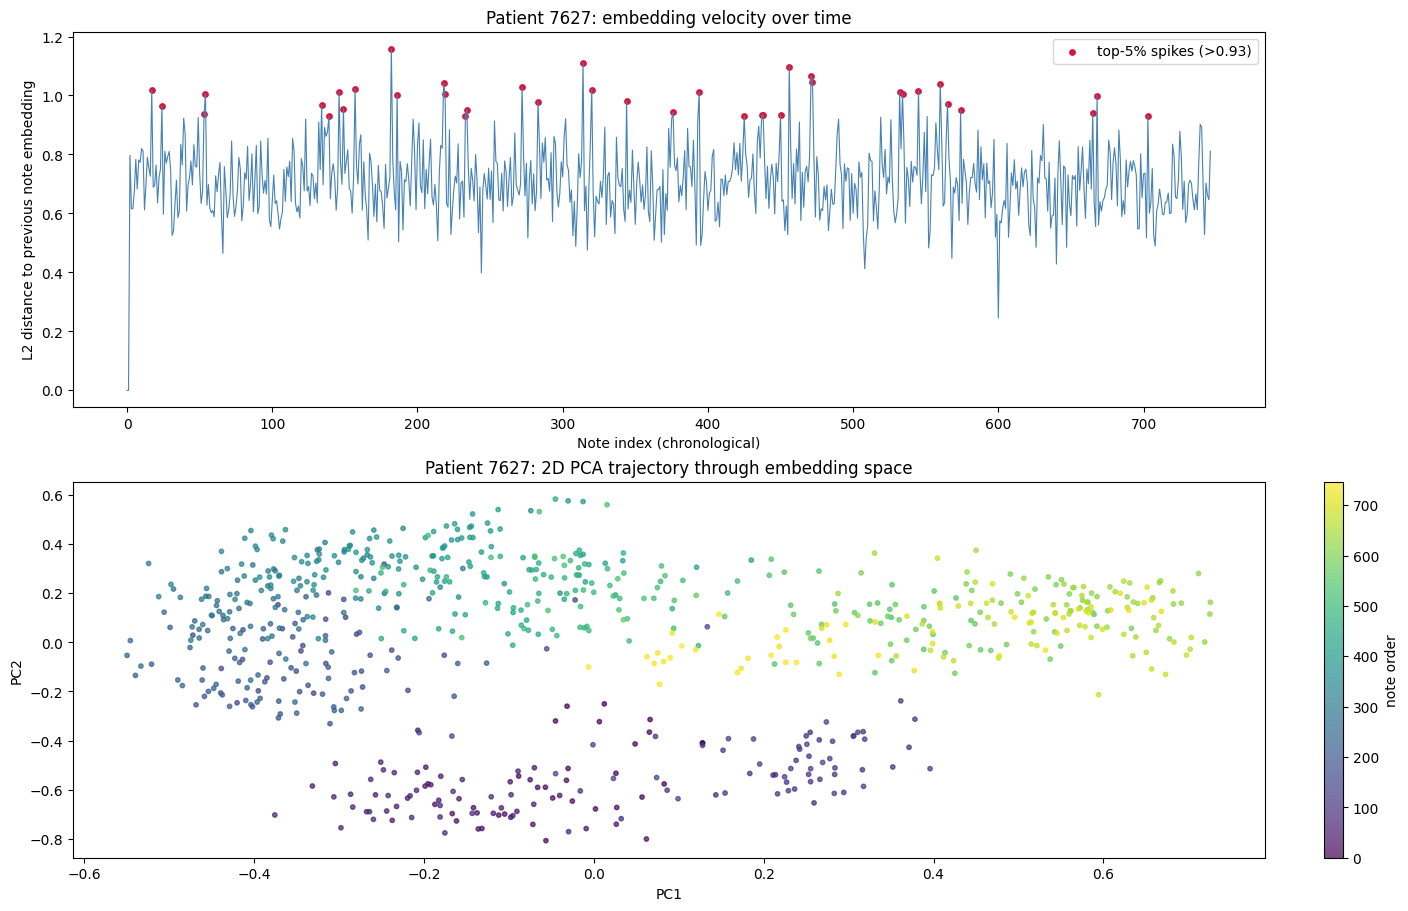

saved -> results/trajectory_patient_7627.png


In [7]:
# Patient with the most anchor notes
busy_sid = int(counts.index[0])
traj = patient_trajectory(corpus, busy_sid)
notes = traj['notes']
print(f'patient {busy_sid}: {len(notes)} notes  median l2_prev={notes["l2_prev"].iloc[1:].median():.3f}  max l2_prev={notes["l2_prev"].max():.3f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)

# Top: embedding velocity over time
ax = axes[0]
ax.plot(range(len(notes)), notes['l2_prev'].values, lw=0.8, color='steelblue')
thresh = float(notes['l2_prev'].iloc[1:].quantile(0.95))
spikes = notes[notes['l2_prev'] > thresh].index
ax.scatter(spikes, notes.loc[spikes, 'l2_prev'], color='crimson', s=15, label=f'top-5% spikes (>{thresh:.2f})')
ax.set_xlabel('Note index (chronological)')
ax.set_ylabel('L2 distance to previous note embedding')
ax.set_title(f'Patient {busy_sid}: embedding velocity over time')
ax.legend()

# Bottom: PCA trajectory
ax = axes[1]
if 'pca1' in notes.columns:
    sc = ax.scatter(notes['pca1'], notes['pca2'], c=range(len(notes)), cmap='viridis', s=10, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='note order')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Patient {busy_sid}: 2D PCA trajectory through embedding space')
fig.savefig('../results/trajectory_patient_{}.png'.format(busy_sid), dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> results/trajectory_patient_{busy_sid}.png')

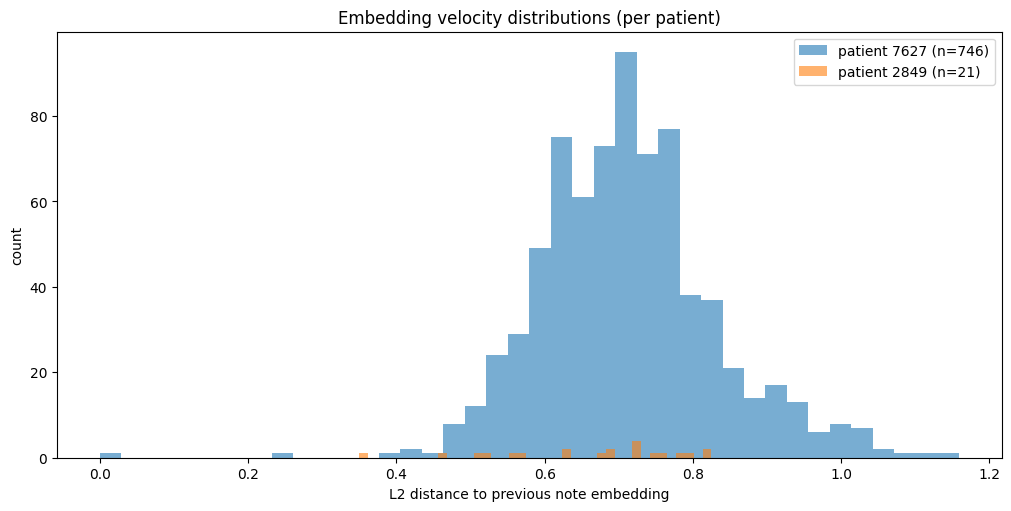

In [8]:
# Compare embedding velocity distributions across patients
med_n = int(counts.index[len(counts) // 2])
med_traj = patient_trajectory(corpus, med_n)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.hist(traj['notes']['l2_prev'].iloc[1:], bins=40, alpha=0.6, label=f'patient {busy_sid} (n={len(traj["notes"])-1})')
ax.hist(med_traj['notes']['l2_prev'].iloc[1:], bins=40, alpha=0.6, label=f'patient {med_n} (n={len(med_traj["notes"])-1})')
ax.set_xlabel('L2 distance to previous note embedding')
ax.set_ylabel('count')
ax.set_title('Embedding velocity distributions (per patient)')
ax.legend()
fig.savefig('../results/trajectory_velocity_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary for the report

Quantitative results to lift into Phase 4 (final report):

- **Search**: top-5 retrieved notes for sepsis-style queries surface ICD codes consistent with the query intent (e.g., `038.42` gram-negative septicemia, `276.52` acute kidney failure for the sepsis query).
- **Cohort discovery (above)**: top-5 nearest patients share ~45% of ICD chapters vs ~22% for random pairs (~2.1× lift), with Mann-Whitney one-sided p ≈ 4.8e-41 — a result that survives any reasonable multiple-comparison correction.
- **Trajectory**: per-patient embedding velocity is non-trivially structured (median L2 ≈ 0.7, max L2 > 1.1 for high-acuity patients), suggesting embedding deltas can be used as an unsupervised proxy for clinical state change.